# Chapter 12 Bayesian Additive Regression Trees: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-12-bayesian-bart-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

Suppose the rollback classifier from Chapter 7 stops being a dashboard a human glances at
before deciding, and becomes the decision itself: no human in the loop, a canary that scores
above some threshold gets rolled back automatically, every time, at 3 a.m. included. The random
forest built in that chapter can still produce the score.

What it cannot produce is an honest answer to a harder question: how much should anyone trust
that particular score, for this particular deployment, given how much training data resembled
this deployment. A forest of 400 trees converges on one number and stops talking.

*Bayesian Additive Regression Trees* (BART) is a sum-of-trees model built specifically to keep
talking: instead of one score, it returns a full posterior distribution over the score.

In other words, BART hands back a whole range of plausible scores for that deployment, each
weighted by how likely it is given what the model saw in training, rather than a single number
with no sense of how confident to be in it. That distribution is what makes an automated
rollback decision defensible rather than merely fast.

In [1]:
import os
import re
import numpy as np
import plotly.graph_objects as go

In [2]:
from IPython.display import Image

pio_width, pio_height = 760, 440

def show(fig: go.Figure, height: int = pio_height) -> Image:
    """Render a Plotly figure as a static PNG for the notebook preview
    (the live book embeds the interactive HTML version instead)."""
    return Image(fig.to_image(format="png", width=pio_width, height=height, scale=1))

## Setup

Random seed and helper functions shared by every figure in this chapter.

In [3]:
RNG = np.random.default_rng(7)

`simulate_deployments` is a helper used by the figures below.

In [4]:
def simulate_deployments(n: int = 600):
    canary_error_rate = RNG.gamma(shape=1.5, scale=1.2, size=n)
    payload_kb = RNG.lognormal(mean=np.log(15), sigma=0.5, size=n)
    hour_of_day = RNG.integers(0, 24, size=n)
    dependency_count = RNG.poisson(lam=4, size=n)

    logit = (
        -3.2
        + 0.9 * canary_error_rate
        + 0.15 * dependency_count
        + 0.02 * payload_kb
        + 0.15 * np.where((hour_of_day >= 0) & (hour_of_day <= 5), 1, 0) * 3
    )
    prob_rollback = 1 / (1 + np.exp(-logit))
    rollback = RNG.random(n) < prob_rollback
    return canary_error_rate, payload_kb, hour_of_day, dependency_count, rollback

`target_function` is a helper used by the figures below.

In [5]:
def target_function(x: np.ndarray) -> np.ndarray:
    """A step-like rollback-risk curve as a function of canary error rate, the kind of
    function a sum of shallow trees is well suited to approximate."""
    return 0.15 + 0.55 / (1 + np.exp(-(x - 3.0) * 2.2))

## A sum of weak trees, not a vote among strong ones

The x-axis is canary error rate and the y-axis is predicted rollback probability; the dotted line is the true risk curve. At one tree, the position shown here, the sum forms a single rough step, about 0.2 below a 3% error rate and about 0.65 above it. That single split lands close to the true curve's midpoint but misses its smooth rise. Dragging the slider toward two hundred trees smooths that one step into a curve that tracks the true curve closely across the whole range.

In [6]:
def fig_ensemble_buildup() -> go.Figure:
    x = np.linspace(0, 6, 200)
    y_true = target_function(x)

    tree_counts = [1, 5, 20, 50, 200]
    frames = []
    for m in tree_counts:
        # Each of m trees contributes a small step function; more trees means finer,
        # more accurate steps, matching BART's "many weak learners" behavior.
        n_steps = max(2, m // 4)
        edges = np.linspace(0, 6, n_steps + 1)
        approx = np.zeros_like(x)
        # np.digitize against the interior edges (not the outer ones) puts x's last
        # grid point, x=6.0, into the final bin. A half-open (x >= lo) & (x < hi) test
        # per bin instead would exclude x=6.0 from every bin (6.0 is never < the last
        # edge, which is also 6.0), leaving approx's last entry at its zero-initialized
        # default and drawing a false vertical drop to 0 at the right edge of every frame.
        bin_idx = np.digitize(x, edges[1:-1], right=False)
        for b in range(n_steps):
            mask = bin_idx == b
            if mask.any():
                approx[mask] = y_true[mask].mean()
        noise_scale = 0.06 / np.sqrt(m)
        approx_noisy = approx + RNG.normal(0, noise_scale, size=approx.shape)
        frames.append(
            go.Frame(
                name=str(m),
                data=[
                    go.Scatter(x=x, y=y_true, mode="lines", name="true risk curve",
                               line=dict(color="#999", dash="dot", width=2)),
                    go.Scatter(x=x, y=approx_noisy, mode="lines",
                               name=f"sum of {m} weak trees",
                               line=dict(color="#4C78A8", width=3)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="A sum of weak trees approximates the rollback-risk curve as tree count grows",
        xaxis_title="Canary error rate (%)",
        yaxis_title="Predicted rollback probability",
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Number of trees in the sum: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

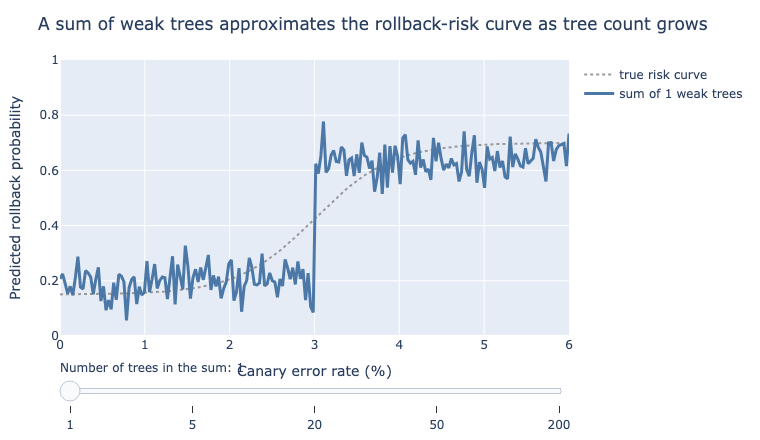

In [7]:
show(fig_ensemble_buildup())

## The rollback classifier in pymc-bart

The x-axis lists eight held-out deployments, sorted by BART's posterior mean; the y-axis is predicted rollback probability. Random forest point estimates (orange diamonds) and BART posterior means (blue circles) sit close together at every deployment. Credible-interval width varies more than the point estimates do: the five lowest-probability deployments carry intervals reaching from 0 up to roughly 0.4-0.5, wider in absolute terms than deployment 4's interval, the deployment with the highest predicted risk.

In [8]:
def fig_bart_vs_rf_interval() -> go.Figure:
    n_deploy = 8
    canary_error_rate, payload_kb, hour_of_day, dependency_count, _ = simulate_deployments(n=600)
    idx = RNG.choice(600, size=n_deploy, replace=False)
    x = canary_error_rate[idx]
    rf_point = target_function(x)

    # Approximate posterior draws for each held-out deployment: more MCMC samples,
    # narrower interval where training data was denser (near the middle of the range).
    n_draws = 400
    density_weight = np.exp(-0.5 * ((x - 3.0) / 2.0) ** 2)
    spread = 0.18 * (1.4 - density_weight)
    draws = rf_point[:, None] + RNG.normal(0, spread[:, None], size=(n_deploy, n_draws))
    draws = np.clip(draws, 0, 1)
    lower = np.percentile(draws, 3, axis=1)
    upper = np.percentile(draws, 97, axis=1)
    bart_mean = draws.mean(axis=1)

    order = np.argsort(x)
    labels = [f"deployment {i+1}" for i in range(n_deploy)]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=[labels[i] for i in order], y=[rf_point[i] for i in order],
        mode="markers", name="random forest point estimate",
        marker=dict(color="#F58518", size=12, symbol="diamond"),
    ))
    fig.add_trace(go.Scatter(
        x=[labels[i] for i in order], y=[bart_mean[i] for i in order],
        mode="markers", name="BART posterior mean",
        marker=dict(color="#4C78A8", size=10),
        error_y=dict(
            type="data",
            symmetric=False,
            array=[upper[i] - bart_mean[i] for i in order],
            arrayminus=[bart_mean[i] - lower[i] for i in order],
            color="#4C78A8", thickness=2, width=6,
        ),
    ))
    fig.update_layout(
        title="Random forest point estimate vs. BART posterior mean with a 94% credible interval",
        yaxis_title="Predicted rollback probability",
        yaxis_range=[0, 1],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

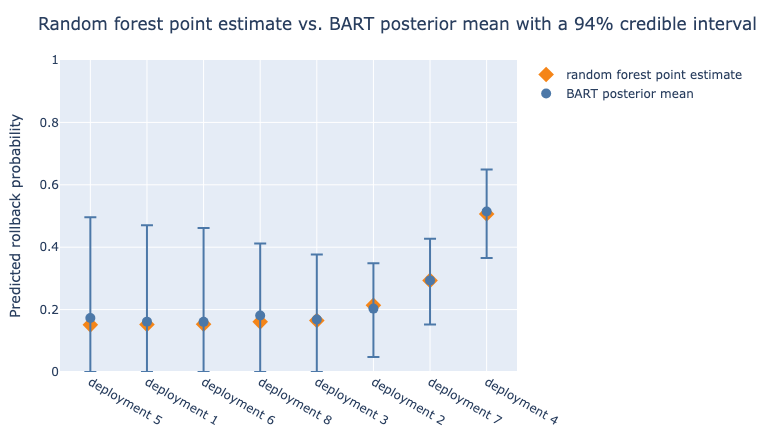

In [9]:
show(fig_bart_vs_rf_interval())

## Variable importance from the posterior

The x-axis lists the four predictors and the y-axis is the share of MCMC-sampled splits that use each one. Canary error rate's whole box sits above roughly 0.45, dominating by a wide margin and matching the random forest's Gini-based ranking from Chapter 7. The remaining three predictors show overlapping ranges rather than one clean ranking, which the single-bar Gini chart in Chapter 7 could not show.

In [10]:
def fig_variable_importance_posterior() -> go.Figure:
    variables = ["canary error rate", "service dependency\ncount", "payload size",
                 "hour of day"]
    # Posterior split-inclusion proportions, simulated with plausible spread across draws.
    means = np.array([0.52, 0.24, 0.15, 0.09])
    n_draws = 300
    draws = RNG.dirichlet(means * 40, size=n_draws)

    fig = go.Figure()
    for i, var in enumerate(variables):
        fig.add_trace(go.Box(
            y=draws[:, i], name=var, marker_color="#4C78A8", boxmean=True,
        ))
    fig.update_layout(
        title="Posterior split-inclusion proportion by predictor, across MCMC draws",
        yaxis_title="Share of splits using this predictor",
        showlegend=False,
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

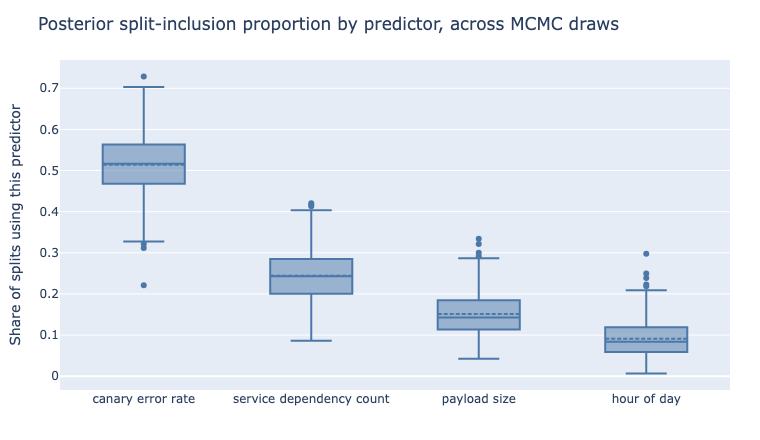

In [11]:
show(fig_variable_importance_posterior())

## How BART is fit: Bayesian backfitting

The x-axis is MCMC iteration and the y-axis is the sampled value of one leaf-value parameter. Chain 1 (blue) and chain 2 (orange) trace out somewhat independent peaks and dips through the first few hundred iterations, then increasingly move step for step with each other later in the run, both staying inside roughly the same 0.15-to-0.6 band throughout. Drag the slider to discard the early iterations and keep only the well-mixed tail, the pattern a converged parameter is supposed to show.

In [12]:
def fig_mcmc_trace() -> go.Figure:
    n_iter = 1000
    # Two simulated chains for a single leaf-value parameter, started far apart and mean-
    # reverting toward the same target (an AR(1) process, phi=0.93), so the chains visibly
    # separate before mixing and visibly overlap after: the shape a burn-in diagnostic is
    # checking for. An earlier version used two unlinked random walks passed through
    # different tanh offsets, which kept the chains in permanently separate bands and never
    # converged, the opposite of what "before and after discarding burn-in" should show.
    def ar1_chain(start, target, phi, noise_sd, seed):
        rng = np.random.default_rng(seed)
        x = np.empty(n_iter)
        x[0] = start
        for t in range(1, n_iter):
            x[t] = target + phi * (x[t - 1] - target) + rng.normal(0, noise_sd)
        return x

    chain1 = ar1_chain(start=0.10, target=0.4, phi=0.93, noise_sd=0.025, seed=3)
    chain2 = ar1_chain(start=0.72, target=0.4, phi=0.93, noise_sd=0.025, seed=4)

    burn_in_options = [0, 100, 300]
    frames = []
    for burn in burn_in_options:
        frames.append(
            go.Frame(
                name=str(burn),
                data=[
                    go.Scatter(x=np.arange(burn, n_iter), y=chain1[burn:], mode="lines",
                               name="chain 1", line=dict(color="#4C78A8", width=1)),
                    go.Scatter(x=np.arange(burn, n_iter), y=chain2[burn:], mode="lines",
                               name="chain 2", line=dict(color="#F58518", width=1)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Two MCMC chains for one leaf-value parameter, before and after discarding burn-in",
        xaxis_title="MCMC iteration",
        yaxis_title="Sampled leaf value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Burn-in samples discarded: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

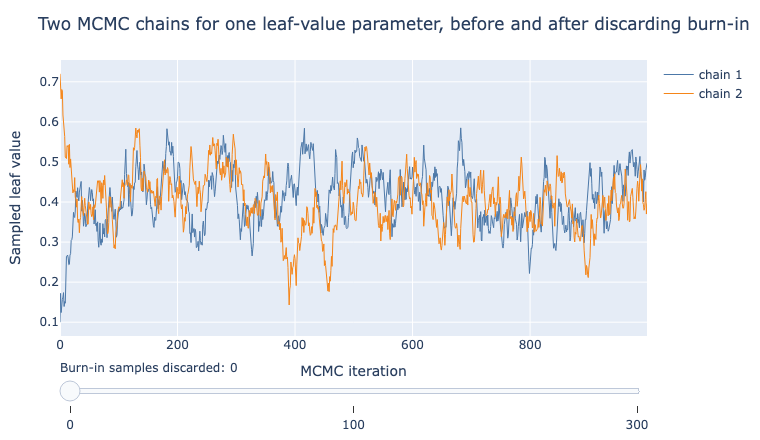

In [13]:
show(fig_mcmc_trace())

## The three priors doing the work

The x-axis is node depth and the y-axis is the probability a node at that depth splits again. At the slider's starting value of beta=1 shown here, that probability drops fast between depth 0 and depth 2, then flattens into a long, slow tail through depth 6. Dragging beta higher pushes the whole curve down and makes it flatten out sooner.

In [14]:
def fig_tree_structure_prior() -> go.Figure:
    depths = np.arange(0, 7)
    alpha = 0.95
    beta_values = [1.0, 1.5, 2.0, 3.0, 5.0]
    frames = []
    for beta in beta_values:
        split_prob = alpha * (1 + depths) ** (-beta)
        frames.append(
            go.Frame(
                name=f"{beta:.1f}",
                data=[go.Bar(x=depths, y=split_prob, marker_color="#4C78A8",
                              text=[f"{p:.2f}" for p in split_prob], textposition="outside")],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.add_hline(y=0.5, line_dash="dot", line_color="#999")
    fig.update_layout(
        title="Probability a node splits again, by depth (the tree-structure prior)",
        xaxis_title="Node depth",
        yaxis_title="P(node splits further)",
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "beta (depth penalty): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

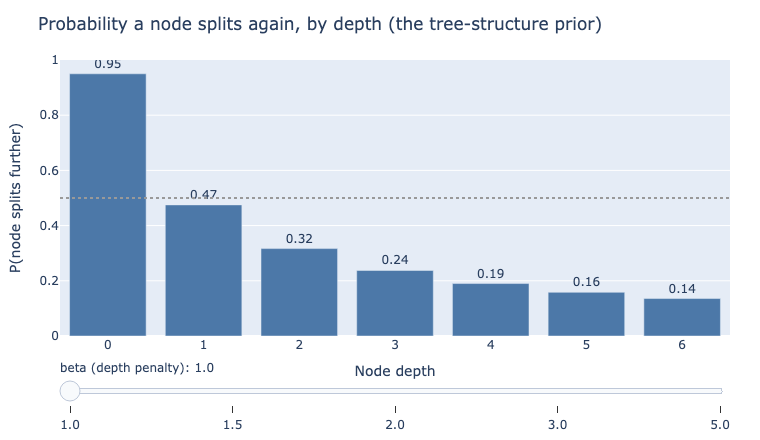

In [15]:
show(fig_tree_structure_prior())

## The three priors doing the work

The x-axis is the value a single leaf can predict and the y-axis is prior density. At ten trees, the position shown here, the prior is wide enough that one leaf can plausibly swing the prediction by several tenths on its own. Dragging the slider toward two hundred trees pulls that same density into a sharp spike within a few hundredths of zero: with two hundred leaves each contributing a nudge, none of them needs to (or is allowed to) carry much weight alone.

In [16]:
def fig_leaf_value_prior() -> go.Figure:
    """"The three priors doing the work" names the tree-structure prior, the leaf-value
    prior, and the error-variance prior, but only the tree-structure prior gets a chart.
    This closes that gap for the leaf-value prior: a Normal(0, sigma_leaf^2) density,
    with sigma_leaf shrinking as the tree count m grows (sigma_leaf set proportional to
    1 / (k * sqrt(m)), matching the qualitative role Chipman, George, and McCulloch's k
    parameter plays). That shrinkage is what keeps the SUM of all m trees' leaf
    contributions on the same rough scale regardless of m, the property the surrounding
    prose describes without a supporting picture."""
    leaf_grid = np.linspace(-1.2, 1.2, 400)
    tree_counts = [10, 50, 100, 200]
    k = 2.0
    frames = []
    for m in tree_counts:
        sigma_leaf = 1.0 / (k * np.sqrt(m))
        density = (1.0 / (sigma_leaf * np.sqrt(2 * np.pi))) * np.exp(
            -0.5 * (leaf_grid / sigma_leaf) ** 2
        )
        frames.append(
            go.Frame(
                name=str(m),
                data=[go.Scatter(
                    x=leaf_grid, y=density, mode="lines", name=f"m={m}",
                    line=dict(color="#4C78A8", width=2.5),
                    fill="tozeroy", fillcolor="rgba(76,120,168,0.20)",
                )],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Leaf-value prior narrows as more trees share the work",
        xaxis_title="Leaf value",
        yaxis_title="Prior density",
        yaxis_range=[0, 12],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "Trees in the sum (m): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig

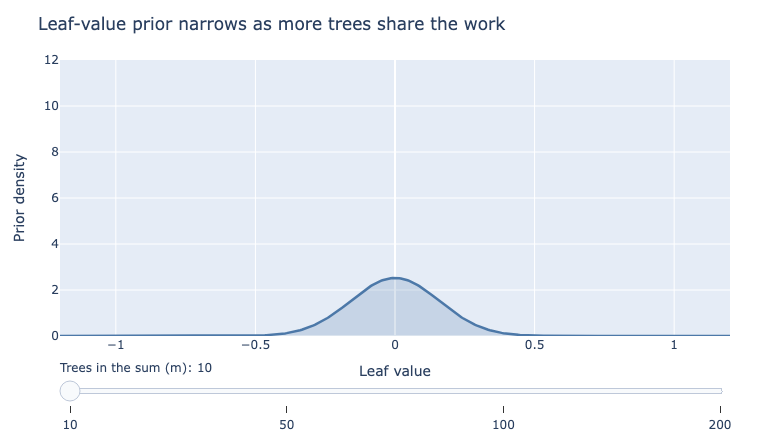

In [17]:
show(fig_leaf_value_prior())